#

In [1052]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
import numpy as np

In [1054]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

In [1056]:
# from google.colab import drive
# drive.mount('/content/drive')

In [1058]:
# df = pd.read_csv("/content/drive/MyDrive/ML/ML_Project/Mall_Customers.csv")
df = pd.read_csv("Mall_Customers.csv")
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [1060]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [1062]:
df = df.drop(columns=['CustomerID'])
df

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


In [1064]:
print(df.isnull().sum())

Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [1066]:
df = df.drop_duplicates()
df

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


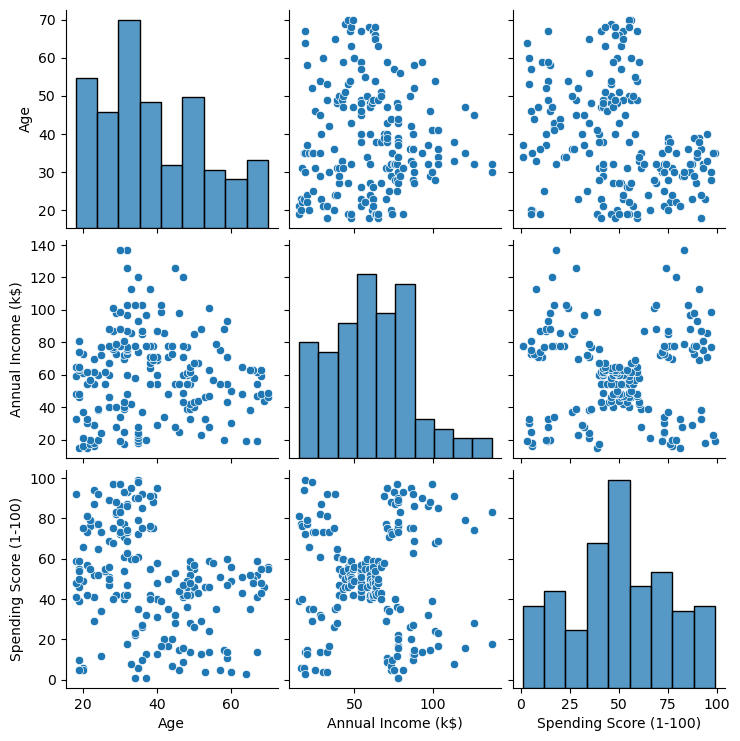

In [1068]:
sns.pairplot(df)
plt.show()

In [1070]:
df['Gender'] = df['Gender'].str.lower()
print("Unique values in gender column:", df['Gender'].unique())

Unique values in gender column: ['male' 'female']


In [1072]:
df['Gender'] = df['Gender'].map({'female': 0, 'male': 1})

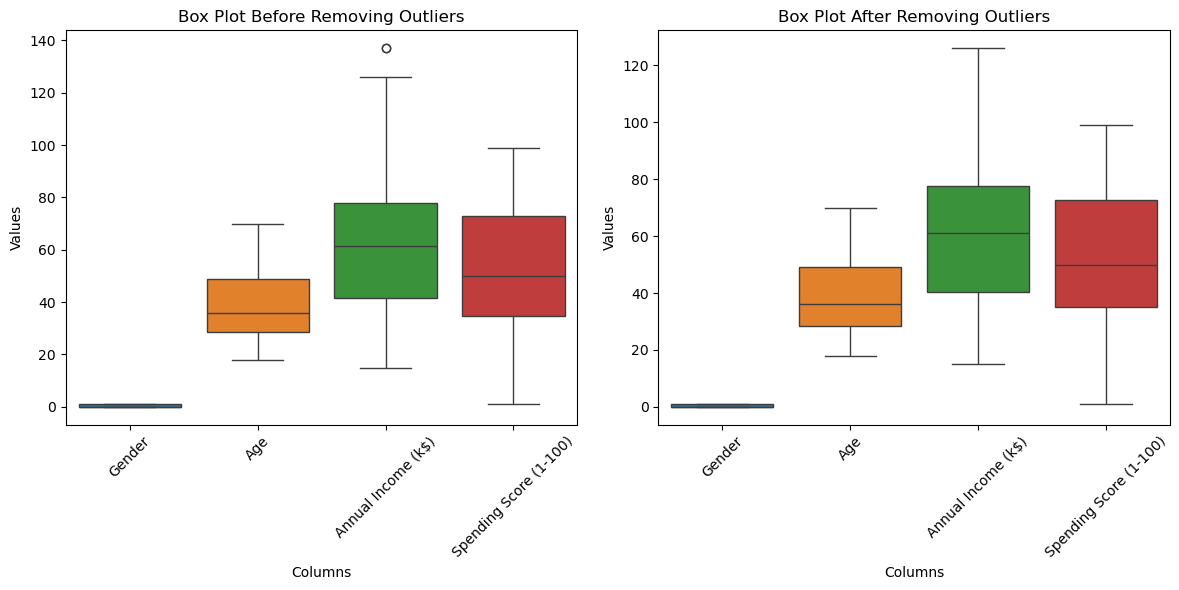

In [1074]:
df_cleaned = df.copy()

for column in df_cleaned.columns:
    Q1 = df_cleaned[column].quantile(0.25)
    Q3 = df_cleaned[column].quantile(0.75)  
    IQR = Q3 - Q1  
    lower_bound = Q1 - 1.5 * IQR  
    upper_bound = Q3 + 1.5 * IQR  

    df_cleaned = df_cleaned[(df_cleaned[column] >= lower_bound) & (df_cleaned[column] <= upper_bound)]

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(data=df)
plt.title('Box Plot Before Removing Outliers')
plt.xlabel('Columns')
plt.ylabel('Values')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.boxplot(data=df_cleaned)
plt.title('Box Plot After Removing Outliers')
plt.xlabel('Columns')
plt.ylabel('Values')

plt.xticks(rotation=45) 

plt.tight_layout()
plt.show()

In [1076]:
df.update(df_cleaned)

In [1078]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

df = pd.DataFrame(scaled_data, columns=df.columns)
df

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1.0,0.019231,0.000000,0.387755
1,1.0,0.057692,0.000000,0.816327
2,0.0,0.038462,0.008197,0.051020
3,0.0,0.096154,0.008197,0.775510
4,0.0,0.250000,0.016393,0.397959
...,...,...,...,...
195,0.0,0.326923,0.860656,0.795918
196,0.0,0.519231,0.909836,0.275510
197,1.0,0.269231,0.909836,0.744898
198,1.0,0.269231,1.000000,0.173469


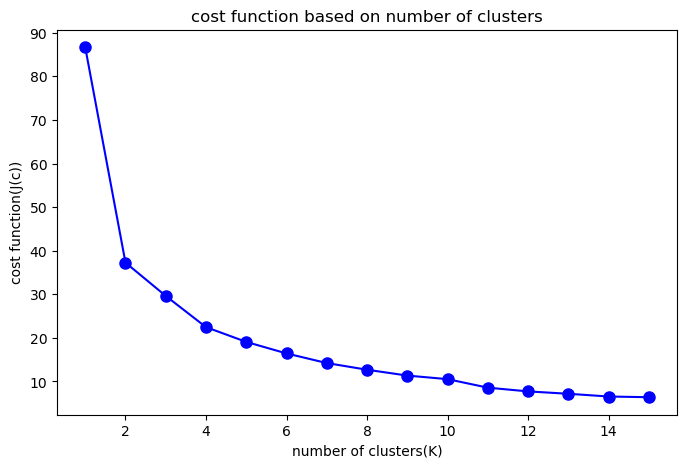

In [1080]:
# محاسبه تابع هزینه برای مقادیر مختلف K
k_values = range(1, 16)  # بررسی تعداد خوشه‌ها از ۱ تا ۱۰
cost_values = []
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(df)  # استفاده از دیتافریم df برای آموزش مدل
    cost_values.append(kmeans.inertia_)  # inertia_ همان تابع هزینه J(c) است

# رسم نمودار
plt.figure(figsize=(8, 5))
plt.plot(k_values, cost_values, 'bo-', markersize=8)
plt.xlabel('number of clusters(K)')
plt.ylabel('cost function(J(c))')
plt.title('cost function based on number of clusters')
plt.show()

In [1082]:
scaled_df = df.copy()
n_clusters=5
kmeans = KMeans(n_clusters)  
scaled_df['K_Means_Cluster'] = kmeans.fit_predict(scaled_data)
scaled_df

,Gender,Age,Annual Income (k$),Spending Score (1-100),K_Means_Cluster
0,1.0,0.019231,0.000000,0.387755,1
1,1.0,0.057692,0.000000,0.816327,1
2,0.0,0.038462,0.008197,0.051020,4
3,0.0,0.096154,0.008197,0.775510,0
4,0.0,0.250000,0.016393,0.397959,0
...,...,...,...,...,...
195,0.0,0.326923,0.860656,0.795918,0
196,0.0,0.519231,0.909836,0.275510,4
197,1.0,0.269231,0.909836,0.744898,1
198,1.0,0.269231,1.000000,0.173469,2


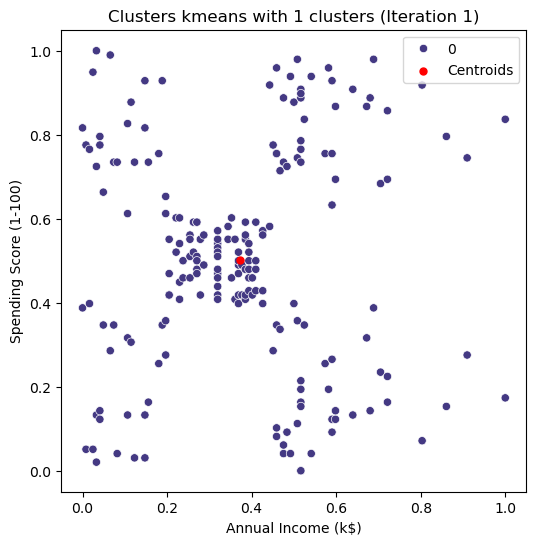

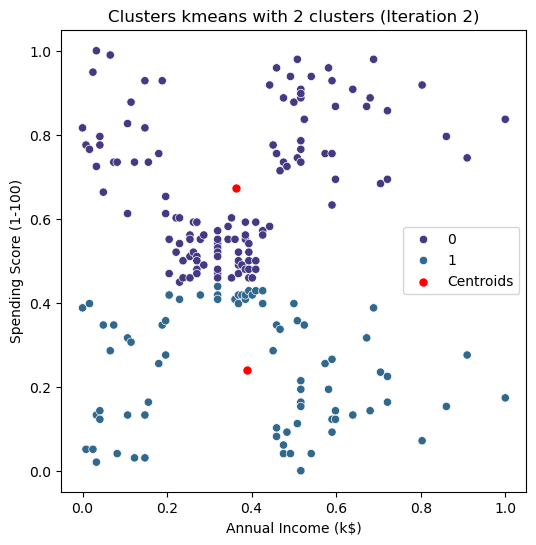

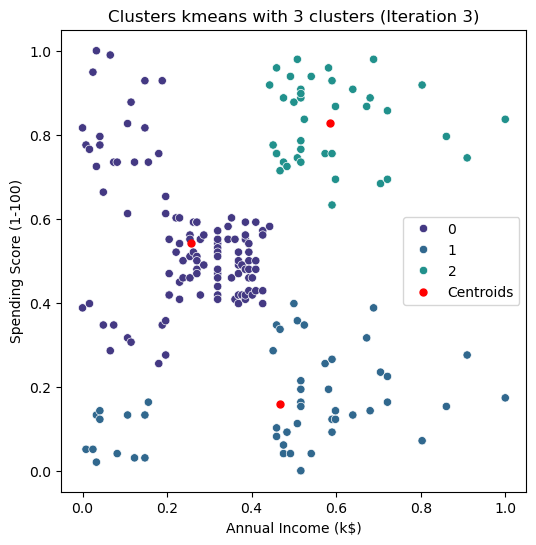

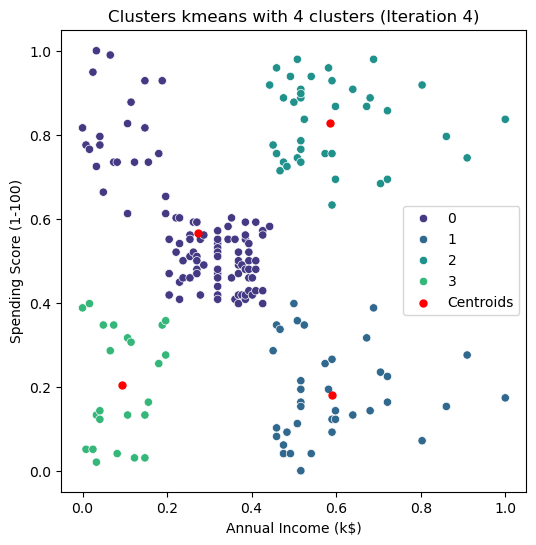

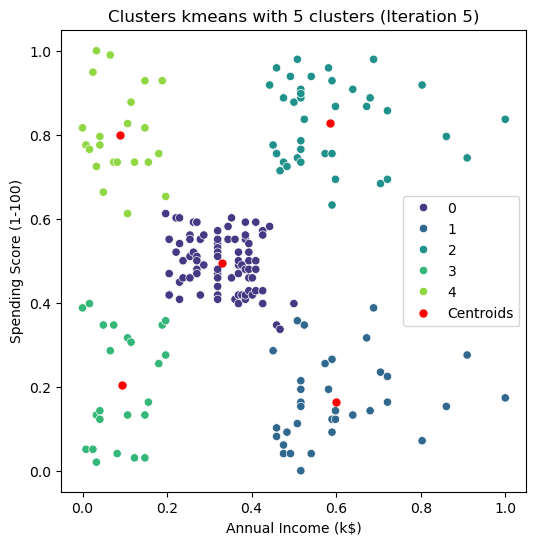

In [1084]:
X = scaled_df[['Annual Income (k$)', 'Spending Score (1-100)']].values

palette = sns.color_palette("viridis", n_clusters)

for i in range(1, n_clusters + 1):    
    kmeans = KMeans(n_clusters=i, random_state=0)
    scaled_df['K_Means_Cluster'] = kmeans.fit_predict(X)
    
    plt.figure(figsize=(6, 6))
    sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', 
                    hue='K_Means_Cluster', data=scaled_df, palette=palette[:i], legend='full')
    
    centroids = kmeans.cluster_centers_
    plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='.', s=100, label='Centroids')

    plt.title(f"Clusters kmeans with {i} clusters (Iteration {i})")
    plt.legend()
    plt.show()

In [1086]:
scaled_df.groupby('K_Means_Cluster').mean()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
K_Means_Cluster,,,,
0,0.407407,0.475309,0.330298,0.495087
1,0.542857,0.444505,0.600000,0.164431
2,0.461538,0.282544,0.586381,0.827839
3,0.391304,0.523411,0.092659,0.203194
4,0.409091,0.139860,0.087928,0.799629


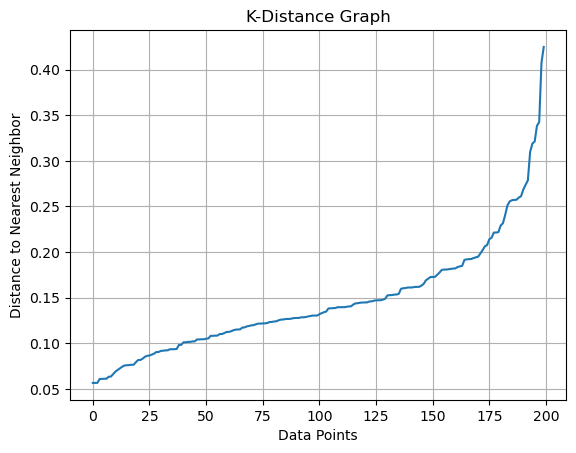

In [1096]:
k = 4
nbrs = NearestNeighbors(n_neighbors=k)
nbrs.fit(scaled_data)

distances, indices = nbrs.kneighbors(df)
distances = np.sort(distances[:, -1])

plt.plot(distances)
plt.xlabel("Data Points")
plt.ylabel("Distance to Nearest Neighbor")
plt.title("K-Distance Graph")
plt.grid(True)
plt.show()

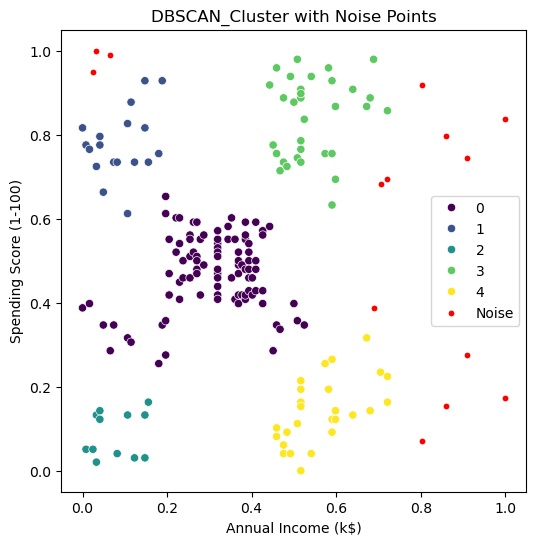

In [1132]:
dbscan = DBSCAN(eps=0.09, min_samples=4)
labels = dbscan.fit_predict(X)

scaled_df['DBSCAN_Cluster'] = labels

plt.figure(figsize=(6, 6))

sns.scatterplot(
    x='Annual Income (k$)', y='Spending Score (1-100)',
    hue='DBSCAN_Cluster', data=scaled_df[scaled_df['DBSCAN_Cluster'] != -1], palette='viridis', legend='full'
)

sns.scatterplot(
    x='Annual Income (k$)', y='Spending Score (1-100)',
    data=scaled_df[scaled_df['DBSCAN_Cluster'] == -1], c='red', marker='.', s=100, label='Noise'
)

plt.title("DBSCAN_Cluster with Noise Points")
plt.legend()
plt.show()